In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
from project_utils import (C_elastic, yield_surface_MC, crosspoint, fnormal_MC, gnormal_MC, f_constraint,
                            Bardet_triaxial, MC_forward, plot_MC, loader_drained, loader_undrained)

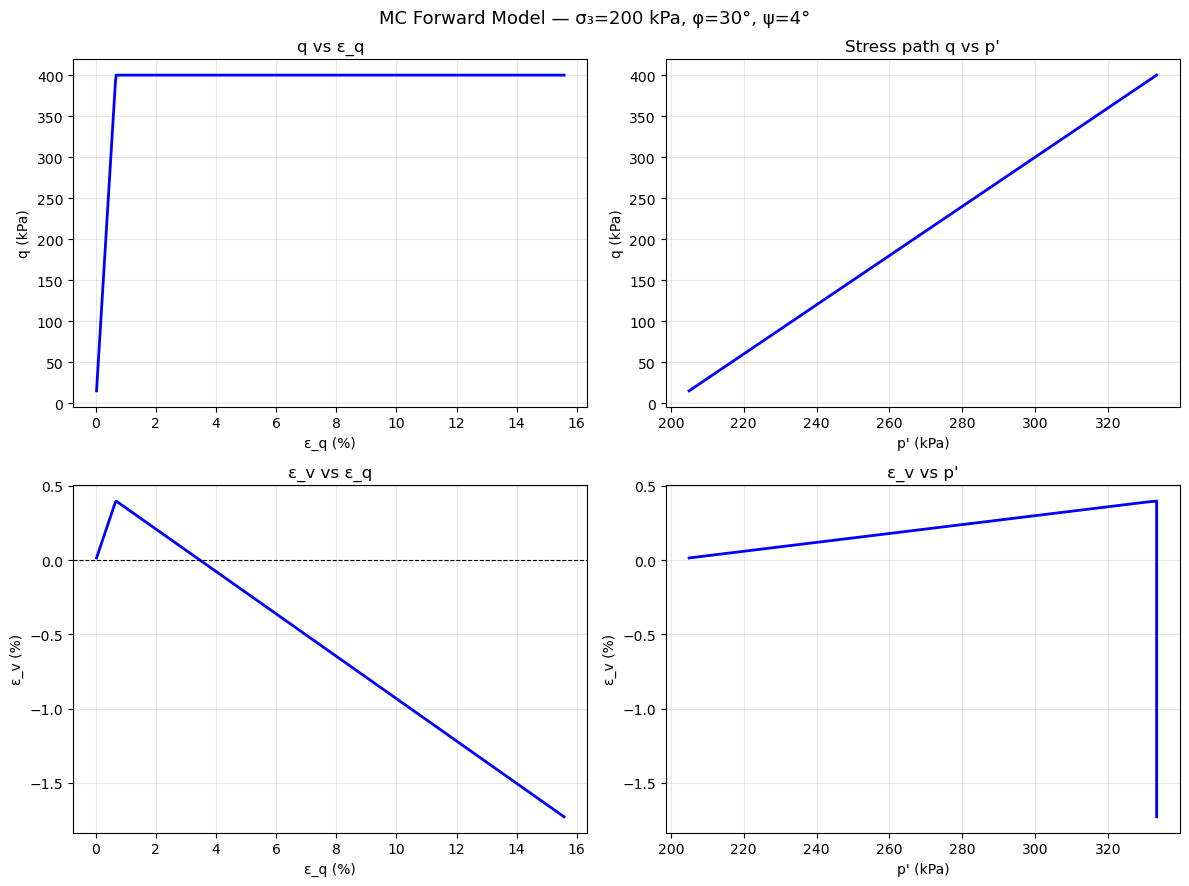

In [2]:
# forward model test run
E  = 50000 #kPa
nu = 0.25
G  = E / (2*(1 + nu))
K  = E / (3*(1 - 2*nu))
phi_deg = 30
psi_deg = 4

params0 =  np.array([K, G, phi_deg, psi_deg])

c       = 0.0
sigma3  = 200.0
    
q, eps_q, eps_v, p = MC_forward(params0, c=c, sigma3=sigma3, eps_max=0.15, n_steps=500, load_tag=110, obs_eps1=None)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].plot(eps_q*100, q, 'b', lw=2)
axes[0,0].set_xlabel('ε_q (%)') 
axes[0,0].set_ylabel('q (kPa)')
axes[0,0].set_title('q vs ε_q') 
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(p, q, 'b', lw=2)
axes[0,1].set_xlabel("p' (kPa)")
axes[0,1].set_ylabel('q (kPa)')
axes[0,1].set_title("Stress path q vs p'")
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(eps_q*100, eps_v*100, 'b', lw=2)
axes[1,0].set_xlabel('ε_q (%)')
axes[1,0].set_ylabel('ε_v (%)')
axes[1,0].set_title('ε_v vs ε_q')
axes[1,0].grid(alpha=0.3)
axes[1,0].axhline(0, color='k', lw=0.8, ls='--')

axes[1,1].plot(p, eps_v*100, 'b', lw=2)
axes[1,1].set_xlabel("p' (kPa)")
axes[1,1].set_ylabel('ε_v (%)')
axes[1,1].set_title("ε_v vs p'")
axes[1,1].grid(alpha=0.3)

plt.suptitle(f'MC Forward Model — σ₃={sigma3:.0f} kPa, φ={phi_deg:.0f}°, ψ={psi_deg:.0f}°', fontsize=13)
plt.tight_layout()
plt.show()

## Inversion

In [3]:
# initial guess
E_0 = 50000 #kPa    
nu = 0.25
K_0  = E_0 / (3*(1 - 2*nu))
G_0  = E_0 / (2*(1 + nu))
phi_deg = 20.0
psi_deg = 0

params = [K_0, G_0, phi_deg, psi_deg]


In [11]:
def objective_function(params, dobs, dpred, wphys, soiltype='sand'):


    q_obs    = dobs['q']
    epsv_obs = dobs['epsv']
    q_pred    = dpred['q']
    epsv_pred = dpred['epsv']

    q_range    = np.ptp(dobs['q'])    if np.ptp(dobs['q'])    > 1e-10 else 1
    epsv_range = np.ptp(dobs['epsv']) if np.ptp(dobs['epsv']) > 1e-10 else 1

    phi_q       = np.sum(((q_pred - q_obs)/q_range)**2) # q data misfit
    phi_epsv    = np.sum(((epsv_pred - epsv_obs)/epsv_range)**2) # epsv data misfit
    phi_data    = phi_q + phi_epsv
    # SMALLNESS removed - prioritized low values which were not necessarily true
    # phi_s       = np.sum((params_scaled - ref)**2)      # smallness

    K, G, phi_deg, psi_deg = params

    if soiltype == 'sand':
        K_min,   G_min   = 10000,  5000
        K_max,   G_max   = 200000, 100000
        phi_min, phi_max = 20,     40
    elif soiltype == 'silt':
        K_min,   G_min   = 5000,   2000
        K_max,   G_max   = 100000, 50000
        phi_min, phi_max = 20,     35

    phi_phys    = (max(0, -phi_deg)**2                  # phi must be positive
                 + max(0, phi_deg - phi_max)**2      # phi maximum bound
                 + max(0, -phi_deg + phi_min)**2     # phi minimum bound
                 + max(0, -psi_deg)**2               # psi must be positive
                 + max(0, psi_deg - phi_deg)**2      # psi <= phi
                 + max(0,  K_min - K)**2             # K minimum bound
                 + max(0,  G_min  - G)**2            # G minimum bound
                 + max(0,  K - K_max)**2             # K maximum bound
                 + max(0,  G - G_max)**2)            # G maximum bound

    phi = phi_data + wphys * phi_phys
    
    return phi, phi_q, phi_epsv, phi_phys

In [12]:
# magnitude check
c=0

params0  = np.array([40000., 20000., 35., 0])
q_pred, eps_q_pred, eps_v_pred, p_pred = MC_forward(params0, c=c, sigma3=dobs['sigma3'], eps_max=dobs['epsa'].max(), n_steps=1000, load_tag=110, obs_eps1=dobs['epsa'])

dpred0   = {'q': q_pred, 'epsv': eps_v_pred}

phi, phi_q, phi_epsv, phi_phys = objective_function(params0, dobs, dpred0, wphys=1.0, soiltype='sand')

print(f"phi_data  = {phi_q + phi_epsv:.4f}")
print(f"phi_q     = {phi_q:.4f}")
print(f"phi_epsv  = {phi_epsv:.4f}")
print(f"phi_phys  = {phi_phys:.4f}")
print(f"phi_total = {phi:.4f}")

print(f"indicates our first guess is pretty far")

phi_data  = 221.8740
phi_q     = 28.0857
phi_epsv  = 193.7884
phi_phys  = 0.0000
phi_total = 221.8740
indicates our first guess is pretty far


In [13]:
print(f"epsv_obs range: {np.ptp(dobs['epsv'])*100:.4f} %")
print(f"epsv_obs max:   {dobs['epsv'].max()*100:.4f} %")
print(f"epsv_obs min:   {dobs['epsv'].min()*100:.4f} %")
print(f"epsv_pred max:  {eps_v_pred.max()*100:.4f} %")
print(f"epsv_pred min:  {eps_v_pred.min()*100:.4f} %")

epsv_obs range: 1.2262 %
epsv_obs max:   1.2262 %
epsv_obs min:   0.0000 %
epsv_pred max:  0.1134 %
epsv_pred min:  0.0114 %


## Newton's Method Inversion

In [14]:
def grad_hess_function(params, dobs, c=0, wphys=1.0, soiltype = 'sand'):
# Taylor Series approx for 2nd derivative: [ f(x+h) - 2f(x) + f(x-h) ] / h^2
    
    grad = np.zeros(len(params))
    hess = np.zeros(len(params))
    sigma3 = dobs['sigma3']
    obs_eps1=dobs['epsa']

    q_now, _, eps_v_now, _  =   MC_forward(params, c, sigma3, eps_max=obs_eps1.max(), n_steps=1000, load_tag=110, obs_eps1=obs_eps1)
    dpred_now = {'q': q_now, 'epsv': eps_v_now}
    phi_now, *_ = objective_function(params, dobs, dpred_now, wphys=wphys, soiltype=soiltype)
    

    for i in range(len(params)):

        dx_frac = 0.01  # scales pertubation size of 1% of parameter value
        dx = dx_frac * abs(params[i]) if abs(params[i]) > 1e-10 else dx_frac
        params_up = params.copy()
        params_up[i] += dx
        params_down = params.copy()
        params_down[i] -= dx

        try:    
            q_up, _, eps_v_up, _ = MC_forward(params_up, c, sigma3, eps_max=obs_eps1.max(), n_steps=1000, load_tag=110, obs_eps1=obs_eps1)
            dpred_up = {'q': q_up, 'epsv': eps_v_up}
            phi_up, *_ = objective_function(params_up, dobs, dpred_up, wphys=wphys, soiltype=soiltype)

            q_down, _, eps_v_down, _ = MC_forward(params_down, c, sigma3, eps_max=obs_eps1.max(), n_steps=1000, load_tag=110, obs_eps1=obs_eps1)
            dpred_down = {'q': q_down, 'epsv': eps_v_down}
            phi_down, *_ = objective_function(params_down, dobs, dpred_down, wphys=wphys, soiltype=soiltype)
            
            grad[i] = (phi_up - phi_down) / (2 * dx)
            hess[i] = (phi_up - 2*phi_now + phi_down) / (dx**2)
        
        except Exception:
            hess[i] = 0.0
            grad[i] = 0.0
    
    return grad, hess

In [ ]:
def newton_inversion(params_init, dobs, c=0, wphys=1, soiltype='sand', max_iter=100, tol_phi=1e-4, tol_hess=1e-4):

    params_now  = np.array(params_init, dtype=float)
    sigma3_obs  = dobs['sigma3']
    epsa_obs    = dobs['epsa']

    q_now, _, eps_v_now, _ = MC_forward(params_now, c, sigma3_obs, eps_max=epsa_obs.max(), n_steps=1000, load_tag=110, obs_eps1=epsa_obs)
    
    dpred_now = {'q': q_now, 'epsv': eps_v_now}
    phi_now, *_        = objective_function(params_now, dobs, dpred_now, wphys, soiltype)
    grad_now, hess_now = grad_hess_function(params_now, dobs, c, wphys, soiltype)

    phi_diff = 9999
    phi_history = [phi_now]
    i = 0

    while (phi_diff > tol_phi) and (i < max_iter):
        i += 1
        n_half = 0
        damping = 1.0 #reset at each iteration - damping used to halve the newton step

        step = np.array([-grad_now[j] / hess_now[j] if abs(hess_now[j]) > tol_hess else 0
                         for j in range(len(params_now))])

        while n_half < 20:
            params_update    = params_now + damping * step
            params_update[0] = max(params_update[0], 1000)
            params_update[1] = max(params_update[1], 500)
            params_update[2] = max(params_update[2], 20)
            params_update[3] = max(params_update[3], 0)

            try: 
                q_update, _, eps_v_update, _ = MC_forward(params_update, c, sigma3_obs, eps_max=epsa_obs.max(), n_steps=1000, load_tag=110, obs_eps1=epsa_obs)
                dpred_update = {'q': q_update, 'epsv': eps_v_update}
                phi_update, *_ = objective_function(params_update, dobs, dpred_update, wphys, soiltype)
            except Exception:
                damping *= 0.5
                n_half += 1
                continue      

            if phi_update < phi_now:
                phi_diff   = abs(phi_update - phi_now)
                params_now = params_update
                phi_now    = phi_update
                grad_now, hess_now = grad_hess_function(params_now, dobs, c, wphys, soiltype)
                phi_history.append(phi_update)
                break
            damping *= 0.5
            n_half += 1

        if n_half == 20:
            print(f"Line search failed at iteration {i} — stopping")
            break

    q_final, _, eps_v_final, p_final = MC_forward(params_now, c, sigma3_obs, eps_max=epsa_obs.max(), n_steps=1000, load_tag=110, obs_eps1=epsa_obs)
    dpred_final = {'q': q_final, 'epsv': eps_v_final, 'p': p_final}
    phi_final, phi_q, phi_epsv, phi_phys = objective_function(params_now, dobs, dpred_final, wphys, soiltype)

    K_opt, G_opt, phi_opt, psi_opt = params_now
    print(f"Converged in {i} iterations")
    print(f"K   = {K_opt/1000:.1f} MPa")
    print(f"G   = {G_opt/1000:.1f} MPa")
    print(f"phi = {phi_opt:.2f}°")
    print(f"psi = {psi_opt:.2f}°")
    print(f"phi_total = {phi_final:.4f}")

    return params_now, phi_history, dpred_final

In [23]:
data_dir = os.path.join('Karlsruhe-fine-sand-database-complete', 'TMD - triaxial-monotonic-drained')
test = 'TMD2'
dobs = loader_drained(test + '.dat', data_dir=data_dir)
# returns epsa, epsv, epsq, p, q , sigma3, time

In [25]:
dq   = dobs['q'][5]   - dobs['q'][0]
deps = dobs['epsa'][5] - dobs['epsa'][0]
E_est = dq / deps
nu = 0.25
K_init = E_est / (3*(1-2*nu))
G_init = E_est / (2*(1+nu))

params_init = np.array([K_init, G_init, 30, 0])
c = 0.

params_opt, phi_history, dpred_final = newton_inversion(params_init, dobs, c=c, wphys=1, soiltype='sand', max_iter=100, tol_phi=1e-6, tol_hess=1e-6)

Converged in 4 iterations
K   = 13.6 MPa
G   = 8.2 MPa
phi = 34.03°
psi = 0.00°
phi_total = 56.4146


In [28]:
grad, hess = grad_hess_function(params_init, dobs, c=c, wphys=1., soiltype='sand')

print("Gradient:")
print(f"  dφ/dK   = {grad[0]:.6f}")
print(f"  dφ/dG   = {grad[1]:.6f}")
print(f"  dφ/dphi = {grad[2]:.6f}")
print(f"  dφ/dpsi = {grad[3]:.6f}")

print("\nHessian diagonal:")
print(f"  d²φ/dK²   = {hess[0]:.6f}")
print(f"  d²φ/dG²   = {hess[1]:.6f}")
print(f"  d²φ/dphi² = {hess[2]:.6f}")
print(f"  d²φ/dpsi² = {hess[3]:.6f}")

print("\nNewton steps (if taken):")
for i in range(4):
    names = ['K', 'G', 'phi', 'psi']
    if abs(hess[i]) > 1e-6:
        step = -grad[i] / hess[i]
        print(f"  step_{names[i]} = {step:.4f}")
    else:
        step = 0.
        print(f"  step_{names[i]} = 0 (hess too flat)")

Gradient:
  dφ/dK   = 0.008599
  dφ/dG   = 0.000228
  dφ/dphi = -11.390690
  dφ/dpsi = 73.969918

Hessian diagonal:
  d²φ/dK²   = -0.000001
  d²φ/dG²   = -0.000000
  d²φ/dphi² = 1.950811
  d²φ/dpsi² = 148.204198

Newton steps (if taken):
  step_K = 0 (hess too flat)
  step_G = 0 (hess too flat)
  step_phi = 5.8390
  step_psi = -0.4991


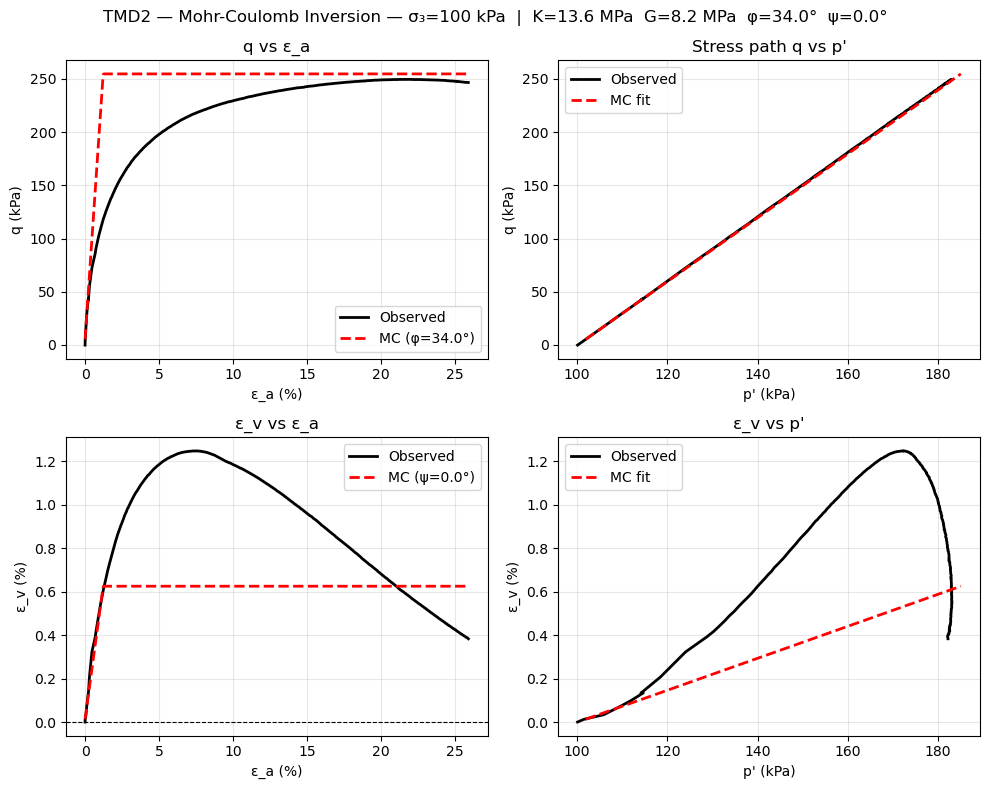

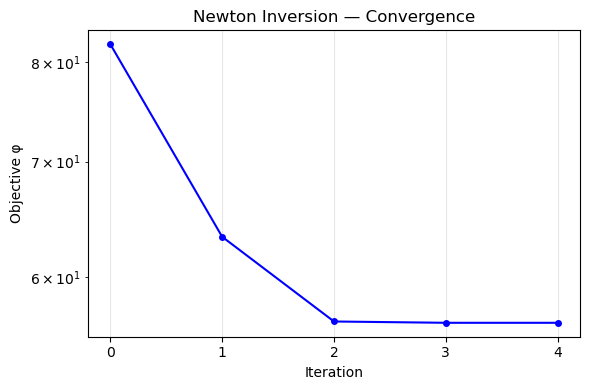

In [27]:
# observed vs predicted
K_opt, G_opt, phi_opt, psi_opt = params_opt

pythonfig, axes = plt.subplots(2, 2, figsize=(10, 8))

# q vs eps_a
axes[0,0].plot(dobs['epsa']*100,        dobs['q'],          'k-',  lw=2, label='Observed')
axes[0,0].plot(dobs['epsa']*100,        dpred_final['q'],   'r--', lw=2, label=f'MC (φ={phi_opt:.1f}°)')
axes[0,0].set_xlabel('ε_a (%)')
axes[0,0].set_ylabel('q (kPa)')
axes[0,0].set_title('q vs ε_a')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# q vs p
axes[0,1].plot(dobs['p'],               dobs['q'],          'k-',  lw=2, label='Observed')
axes[0,1].plot(dpred_final['p'],        dpred_final['q'],   'r--', lw=2, label='MC fit')
axes[0,1].set_xlabel("p' (kPa)")
axes[0,1].set_ylabel('q (kPa)')
axes[0,1].set_title("Stress path q vs p'")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# epsv vs eps_a
axes[1,0].plot(dobs['epsa']*100,        dobs['epsv']*100,         'k-',  lw=2, label='Observed')
axes[1,0].plot(dobs['epsa']*100,        dpred_final['epsv']*100,  'r--', lw=2, label=f'MC (ψ={psi_opt:.1f}°)')
axes[1,0].set_xlabel('ε_a (%)')
axes[1,0].set_ylabel('ε_v (%)')
axes[1,0].set_title('ε_v vs ε_a')
axes[1,0].axhline(0, color='k', lw=0.8, ls='--')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# epsv vs p
axes[1,1].plot(dobs['p'],               dobs['epsv']*100,         'k-',  lw=2, label='Observed')
axes[1,1].plot(dpred_final['p'],        dpred_final['epsv']*100,  'r--', lw=2, label='MC fit')
axes[1,1].set_xlabel("p' (kPa)")
axes[1,1].set_ylabel('ε_v (%)')
axes[1,1].set_title("ε_v vs p'")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle(f'{test} — Mohr-Coulomb Inversion — σ₃={dobs["sigma3"]:.0f} kPa  |  '
             f'K={K_opt/1000:.1f} MPa  G={G_opt/1000:.1f} MPa  '
             f'φ={phi_opt:.1f}°  ψ={psi_opt:.1f}°', fontsize=12)
plt.tight_layout()
plt.show()

# convergence plot
plt.figure(figsize=(6, 4))
plt.plot(phi_history, 'b-o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Objective φ')
plt.title('Newton Inversion — Convergence')
plt.yscale('log')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()